# Synthetic Data Generation for LVC Dataset

This notebook generates synthetic data using:
- CTGAN
- TVAE

Scenarios:
- 10x dataset
- 30x dataset

Key principles:
- No data leakage (train only)
- Balanced classes
- Clinical consistency

In [4]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sdv.single_table import CTGANSynthesizer, TVAESynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.sampling import Condition

import warnings
warnings.filterwarnings("ignore")

In [5]:
DATA_PATH = "../data/raw/leish_dataset.csv"
TARGET = "diagnosis"

SEEDS = [41, 42, 46]
TEST_SIZE = 0.30
MIN_BREED_COUNT = 10

OUTPUT_DIR = "../data/synthetic"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
df = pd.read_csv(DATA_PATH)

# Agrupar raças raras
breed_counts = df["breed_name"].value_counts(dropna=False)
rare_breeds = breed_counts[breed_counts < MIN_BREED_COUNT].index
df["breed_name"] = df["breed_name"].replace(rare_breeds, "other")

print("Shape:", df.shape)
display(df.head())

Shape: (456, 17)


,diagnosis,general_state,ectoparasites,nutritional_state,coat,nails,mucosa_color,muzzle_ear_lesion,lymph_nodes,blepharitis,conjunctivitis,alopecia,bleeding,skin_lesion,muzzle_lip_depigmentation,animal_sex,breed_name
0,negativo,bom,ausente,adequado,normal,normal,normal,presente,normal,ausente,Ausente,ausente,presente,Ausente,ausente,M,SRD
1,negativo,bom,ausente,adequado,normal,normal,normal,ausente,normal,ausente,Ausente,ausente,ausente,Ausente,ausente,M,SRD
2,negativo,bom,leve,adequado,normal,normal,normal,ausente,normal,ausente,Ausente,ausente,presente,Ausente,ausente,M,Poodle
3,negativo,bom,ausente,adequado,normal,leves_moderadas,normal,ausente,normal,ausente,Ausente,ausente,ausente,Ausente,ausente,F,other
4,negativo,bom,leve,leve_moderado,normal,leves_moderadas,normal,ausente,leves_moderadas,ausente,Ausente,ausente,ausente,Ausente,ausente,F,SRD


In [7]:
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True))

diagnosis
negativo    320
positivo    136
Name: count, dtype: int64
diagnosis
negativo    0.701754
positivo    0.298246
Name: proportion, dtype: float64


In [8]:
metadata = SingleTableMetadata()

for col in df.columns:
    metadata.add_column(
        column_name=col,
        sdtype="categorical"
    )

print("Metadata configured manually.")
metadata

Metadata configured manually.


{
    "columns": {
        "diagnosis": {
            "sdtype": "categorical"
        },
        "general_state": {
            "sdtype": "categorical"
        },
        "ectoparasites": {
            "sdtype": "categorical"
        },
        "nutritional_state": {
            "sdtype": "categorical"
        },
        "coat": {
            "sdtype": "categorical"
        },
        "nails": {
            "sdtype": "categorical"
        },
        "mucosa_color": {
            "sdtype": "categorical"
        },
        "muzzle_ear_lesion": {
            "sdtype": "categorical"
        },
        "lymph_nodes": {
            "sdtype": "categorical"
        },
        "blepharitis": {
            "sdtype": "categorical"
        },
        "conjunctivitis": {
            "sdtype": "categorical"
        },
        "alopecia": {
            "sdtype": "categorical"
        },
        "bleeding": {
            "sdtype": "categorical"
        },
        "skin_lesion": {
            "sdtype":

In [9]:
# Metadata configuration (manual to avoid semantic errors like "Florida")

from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

for col in df.columns:
    metadata.add_column(
        column_name=col,
        sdtype="categorical"
    )

print("Metadata configured manually.")
metadata

Metadata configured manually.


{
    "columns": {
        "diagnosis": {
            "sdtype": "categorical"
        },
        "general_state": {
            "sdtype": "categorical"
        },
        "ectoparasites": {
            "sdtype": "categorical"
        },
        "nutritional_state": {
            "sdtype": "categorical"
        },
        "coat": {
            "sdtype": "categorical"
        },
        "nails": {
            "sdtype": "categorical"
        },
        "mucosa_color": {
            "sdtype": "categorical"
        },
        "muzzle_ear_lesion": {
            "sdtype": "categorical"
        },
        "lymph_nodes": {
            "sdtype": "categorical"
        },
        "blepharitis": {
            "sdtype": "categorical"
        },
        "conjunctivitis": {
            "sdtype": "categorical"
        },
        "alopecia": {
            "sdtype": "categorical"
        },
        "bleeding": {
            "sdtype": "categorical"
        },
        "skin_lesion": {
            "sdtype":

In [10]:
def make_balanced_target_counts(n_samples):
    half = n_samples // 2
    return {
        "negativo": half,
        "positivo": n_samples - half
    }

In [11]:
summary_rows = []
generated_datasets = {}

In [12]:
for seed in SEEDS:
    print("=" * 90)
    print(f"SEED {seed}")
    print("=" * 90)

    train_df, test_df = train_test_split(
        df,
        test_size=TEST_SIZE,
        stratify=df[TARGET],
        random_state=seed
    )

    print("Train shape:", train_df.shape)
    print("Test shape:", test_df.shape)
    print("Train distribution:")
    print(train_df[TARGET].value_counts(normalize=True))

    real_train_size = len(train_df)

    scenario_sizes = {
        "10x": real_train_size * 10,
        "30x": real_train_size * 30
    }

    synthesizers = {
        "CTGAN": CTGANSynthesizer(metadata),
        "TVAE": TVAESynthesizer(metadata)
    }

    for synth_name, synthesizer in synthesizers.items():

        print("-" * 60)
        print(f"Training {synth_name}")

        synthesizer.fit(train_df)

        for scenario_name, n_samples in scenario_sizes.items():

            target_counts = make_balanced_target_counts(n_samples)

            synthetic_parts = []

            for cls_label, cls_n in target_counts.items():

                condition = Condition(
                    num_rows=cls_n,
                    column_values={TARGET: cls_label}
                )

                sampled = synthesizer.sample_from_conditions(
                    conditions=[condition]
                )

                synthetic_parts.append(sampled)

            synthetic_df = (
                pd.concat(synthetic_parts, axis=0)
                .sample(frac=1, random_state=seed)
                .reset_index(drop=True)
            )

            # Garantir ordem correta das colunas
            synthetic_df = synthetic_df[df.columns.tolist()]

            file_name = f"{synth_name.lower()}_{scenario_name}_seed{seed}.csv"
            path = os.path.join(OUTPUT_DIR, file_name)

            synthetic_df.to_csv(path, index=False)

            generated_datasets[(seed, synth_name, scenario_name)] = synthetic_df

            summary_rows.append({
                "seed": seed,
                "generator": synth_name,
                "scenario": scenario_name,
                "real_train_size": real_train_size,
                "synthetic_size": len(synthetic_df),
                "neg_ratio": (synthetic_df[TARGET] == "negativo").mean(),
                "pos_ratio": (synthetic_df[TARGET] == "positivo").mean(),
                "file_name": file_name
            })

            print(
                f"{synth_name} | {scenario_name} | "
                f"shape={synthetic_df.shape} | "
                f"pos_ratio={(synthetic_df[TARGET]=='positivo').mean():.3f}"
            )

SEED 41
Train shape: (319, 17)
Test shape: (137, 17)
Train distribution:
diagnosis
negativo    0.702194
positivo    0.297806
Name: proportion, dtype: float64
------------------------------------------------------------
Training CTGAN


Sampling conditions: 100%|█████████████████████████████████████████████████████████████████████| 1595/1595 [00:00<00:00, 8821.04it/s]


CTGAN | 10x | shape=(3190, 17) | pos_ratio=0.500


Sampling conditions: 100%|████████████████████████████████████████████████████████████████████| 4785/4785 [00:00<00:00, 13820.23it/s]


CTGAN | 30x | shape=(9570, 17) | pos_ratio=0.500
------------------------------------------------------------
Training TVAE


...

CTGAN | 30x | shape=(9570, 17) | pos_ratio=0.500
------------------------------------------------------------
Training TVAE


Sampling conditions: 100%|█████████████████████████████████████████████████████████████████████| 1595/1595 [00:00<00:00, 4211.06it/s]


TVAE | 10x | shape=(3190, 17) | pos_ratio=0.500


Sampling conditions: 100%|████████████████████████████████████████████████████████████████████| 4785/4785 [00:00<00:00, 12490.02it/s]

TVAE | 30x | shape=(9570, 17) | pos_ratio=0.500


In [13]:
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,seed,generator,scenario,real_train_size,synthetic_size,neg_ratio,pos_ratio,file_name
0,41,CTGAN,10x,319,3190,0.5,0.5,ctgan_10x_seed41.csv
1,41,CTGAN,30x,319,9570,0.5,0.5,ctgan_30x_seed41.csv
2,41,TVAE,10x,319,3190,0.5,0.5,tvae_10x_seed41.csv
3,41,TVAE,30x,319,9570,0.5,0.5,tvae_30x_seed41.csv
4,42,CTGAN,10x,319,3190,0.5,0.5,ctgan_10x_seed42.csv
5,42,CTGAN,30x,319,9570,0.5,0.5,ctgan_30x_seed42.csv
6,42,TVAE,10x,319,3190,0.5,0.5,tvae_10x_seed42.csv
7,42,TVAE,30x,319,9570,0.5,0.5,tvae_30x_seed42.csv
8,46,CTGAN,10x,319,3190,0.5,0.5,ctgan_10x_seed46.csv
9,46,CTGAN,30x,319,9570,0.5,0.5,ctgan_30x_seed46.csv


In [14]:
summary_df.to_csv("../results/tables/synthetic_generation_summary.csv", index=False)

print("Summary saved.")

Summary saved.


In [15]:
example_key = list(generated_datasets.keys())[0]
example_df = generated_datasets[example_key]

print("Example dataset:", example_key)
display(example_df.head())

print("\nClass distribution:")
print(example_df[TARGET].value_counts(normalize=True))

print("\nChecking for invalid categories...")

for col in df.columns:
    real_values = set(df[col].dropna().astype(str).unique())
    synth_values = set(example_df[col].dropna().astype(str).unique())

    invalid = synth_values - real_values

    if invalid:
        print(f"{col} -> INVALID VALUES: {invalid}")

Example dataset: (41, 'CTGAN', '10x')


,diagnosis,general_state,ectoparasites,nutritional_state,coat,nails,mucosa_color,muzzle_ear_lesion,lymph_nodes,blepharitis,conjunctivitis,alopecia,bleeding,skin_lesion,muzzle_lip_depigmentation,animal_sex,breed_name
0,positivo,bom,leve,leve_moderado,leves_moderadas,leves_moderadas,levemente_hipercorada,ausente,leves_moderadas,ausente,Ausente,ausente,ausente,Grave/Generalizada,ausente,F,SRD
1,positivo,bom,leve,leve_moderado,normal,normal,levemente_hipercorada,presente,leves_moderadas,ausente,Conjuntivite Leve,presente,ausente,Ausente,presente,F,Pinscher
2,negativo,regular,leve,leve_moderado,leves_moderadas,normal,congesta,ausente,leves_moderadas,ausente,Ausente,presente,ausente,Ausente,presente,F,Pinscher
3,negativo,regular,leve,grave,normal,normal,normal,presente,leves_moderadas,ausente,Ausente,ausente,ausente,Ausente,ausente,M,SRD
4,positivo,bom,leve,adequado,normal,normal,levemente_hipercorada,ausente,leves_moderadas,ausente,Ausente,ausente,ausente,Leve/Moderada,presente,F,SRD



Class distribution:
diagnosis
positivo    0.5
negativo    0.5
Name: proportion, dtype: float64

Checking for invalid categories...


In [16]:
for col in df.columns:
    print("\n", col)
    print("Real:")
    print(df[col].value_counts(normalize=True).head())

    print("Synthetic:")
    print(example_df[col].value_counts(normalize=True).head())


 diagnosis
Real:
diagnosis
negativo    0.701754
positivo    0.298246
Name: proportion, dtype: float64
Synthetic:
diagnosis
positivo    0.5
negativo    0.5
Name: proportion, dtype: float64

 general_state
Real:
general_state
bom        0.934211
regular    0.063596
ruim       0.002193
Name: proportion, dtype: float64
Synthetic:
general_state
bom        0.898119
regular    0.101881
Name: proportion, dtype: float64

 ectoparasites
Real:
ectoparasites
leve       0.451754
ausente    0.412281
grave      0.135965
Name: proportion, dtype: float64
Synthetic:
ectoparasites
ausente    0.471473
leve       0.389342
grave      0.139185
Name: proportion, dtype: float64

 nutritional_state
Real:
nutritional_state
adequado         0.690789
leve_moderado    0.276316
grave            0.032895
Name: proportion, dtype: float64
Synthetic:
nutritional_state
adequado         0.656113
leve_moderado    0.288401
grave            0.055486
Name: proportion, dtype: float64

 coat
Real:
coat
normal             0.528

In [17]:
from scipy.stats import chisquare
from scipy.spatial.distance import jensenshannon

In [18]:
def compare_distributions(real_series, synth_series):
    
    real_dist = real_series.value_counts(normalize=True)
    synth_dist = synth_series.value_counts(normalize=True)

    all_categories = set(real_dist.index).union(set(synth_dist.index))

    real_probs = np.array([real_dist.get(cat, 0) for cat in all_categories])
    synth_probs = np.array([synth_dist.get(cat, 0) for cat in all_categories])

    # evitar zeros
    real_probs += 1e-8
    synth_probs += 1e-8

    # normalizar
    real_probs = real_probs / real_probs.sum()
    synth_probs = synth_probs / synth_probs.sum()

    # métricas
    jsd = jensenshannon(real_probs, synth_probs)
    tvd = np.sum(np.abs(real_probs - synth_probs)) / 2

    # chi-square
    chi_stat, chi_p = chisquare(f_obs=synth_probs, f_exp=real_probs)

    return {
        "JSD": jsd,
        "TVD": tvd,
        "Chi2_p_value": chi_p
    }

In [19]:
results_stats = []

example_key = list(generated_datasets.keys())[0]
example_df = generated_datasets[example_key]

for col in df.columns:
    
    stats = compare_distributions(df[col], example_df[col])
    
    results_stats.append({
        "feature": col,
        "JSD": stats["JSD"],
        "TVD": stats["TVD"],
        "Chi2_p_value": stats["Chi2_p_value"]
    })

stats_df = pd.DataFrame(results_stats)

display(stats_df.sort_values(by="JSD", ascending=False))

,feature,JSD,TVD,Chi2_p_value
10,conjunctivitis,0.147150,0.181300,0.889608
0,diagnosis,0.146272,0.201754,0.659209
11,alopecia,0.120554,0.159718,0.712238
14,muzzle_lip_depigmentation,0.117159,0.152812,0.718404
4,coat,0.109578,0.153901,0.953572
5,nails,0.109290,0.152253,0.748635
7,muzzle_ear_lesion,0.095606,0.133772,0.781269
6,mucosa_color,0.084083,0.113063,0.969285
15,animal_sex,0.065443,0.092160,0.853756
13,skin_lesion,0.062814,0.078847,0.982674


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [21]:
def plot_distribution_comparison(real_df, synth_df, column):
    
    real_dist = real_df[column].value_counts(normalize=True)
    synth_dist = synth_df[column].value_counts(normalize=True)

    categories = sorted(set(real_dist.index).union(set(synth_dist.index)))

    real_values = [real_dist.get(cat, 0) for cat in categories]
    synth_values = [synth_dist.get(cat, 0) for cat in categories]

    x = np.arange(len(categories))

    plt.figure(figsize=(8, 4))
    
    plt.bar(x - 0.2, real_values, width=0.4, label="Real")
    plt.bar(x + 0.2, synth_values, width=0.4, label="Synthetic")

    plt.xticks(x, categories, rotation=45, ha="right")
    plt.title(f"Distribution Comparison: {column}")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [23]:
# Escolher um dataset (ex: CTGAN 10x seed 41)

example_key = (41, "CTGAN", "10x")
example_df = generated_datasets[example_key]

print("Using:", example_key)

Using: (41, 'CTGAN', '10x')


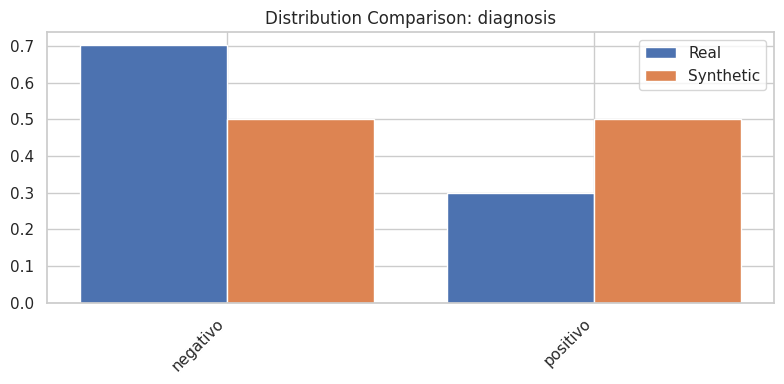

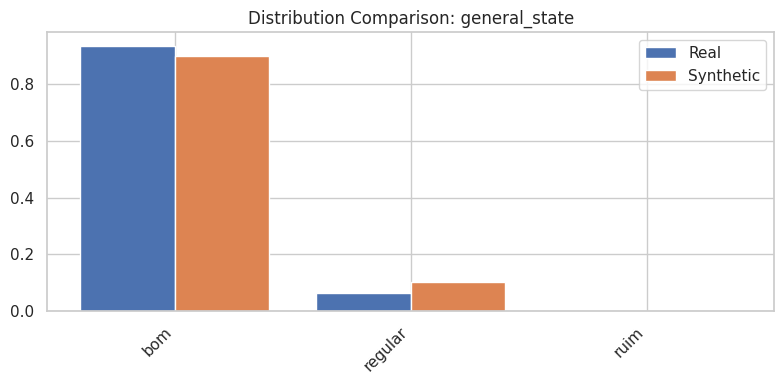

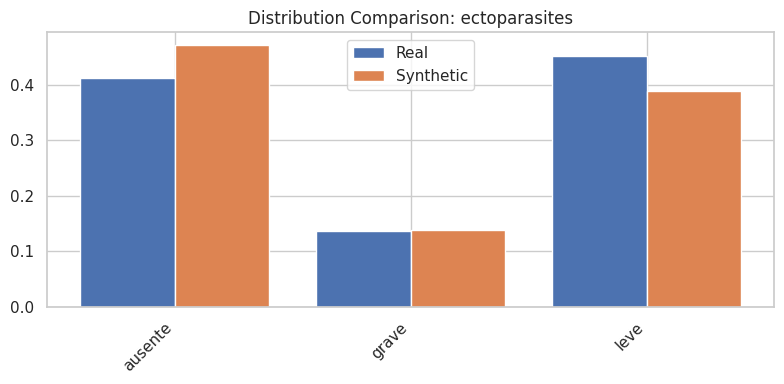

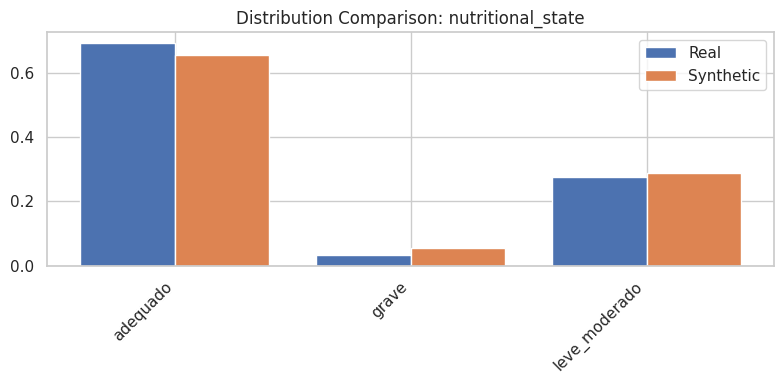

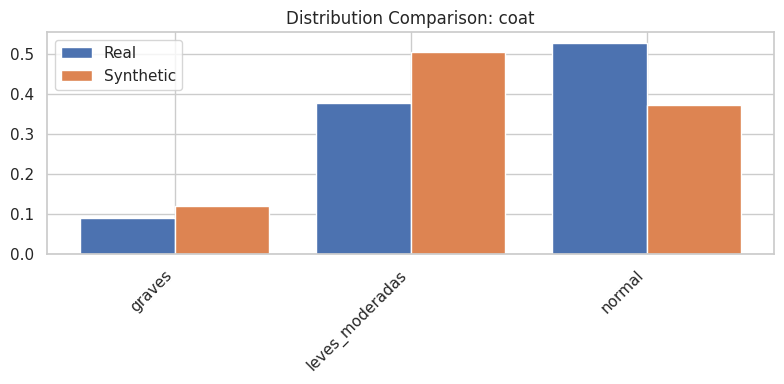

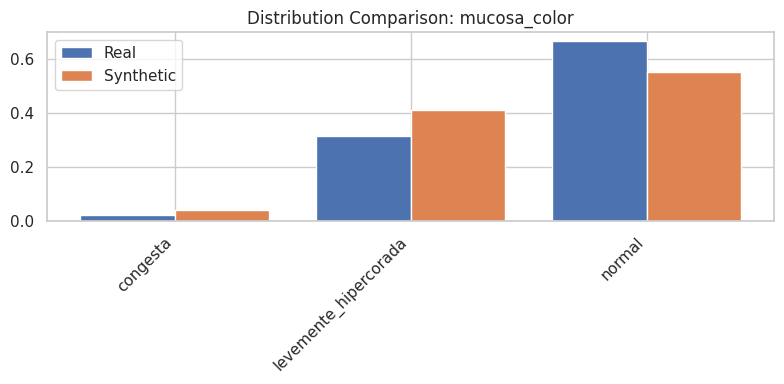

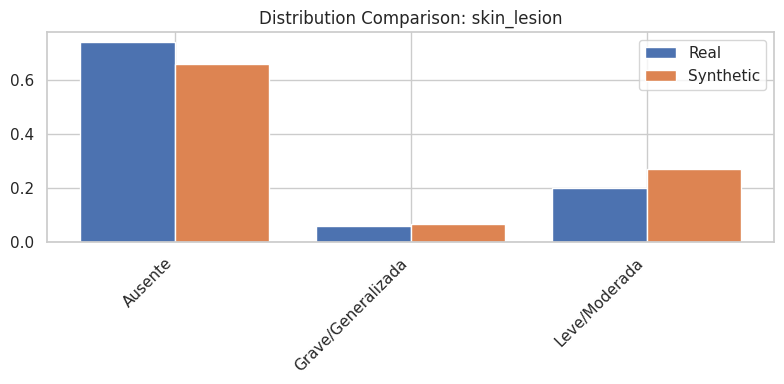

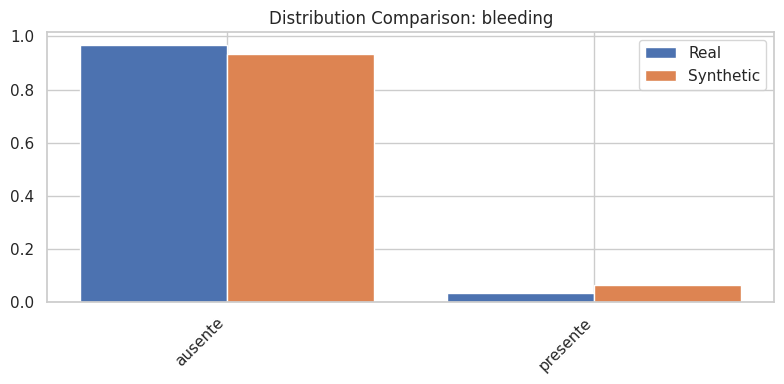

In [24]:
columns_to_plot = [
    "diagnosis",
    "general_state",
    "ectoparasites",
    "nutritional_state",
    "coat",
    "mucosa_color",
    "skin_lesion",
    "bleeding"
]

for col in columns_to_plot:
    plot_distribution_comparison(df, example_df, col)

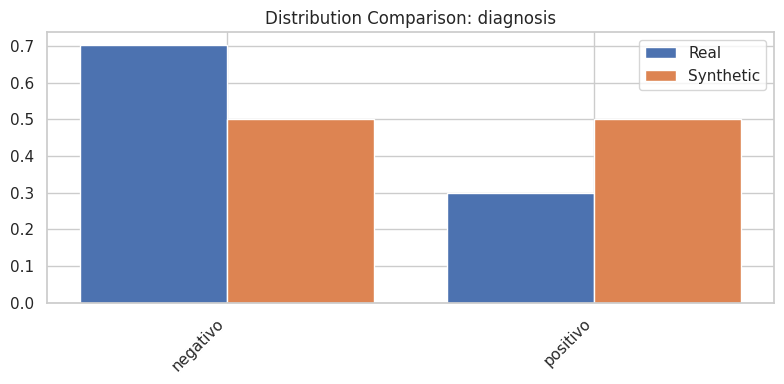

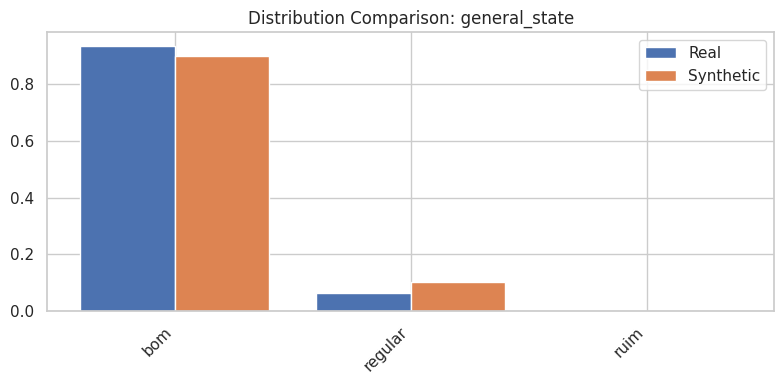

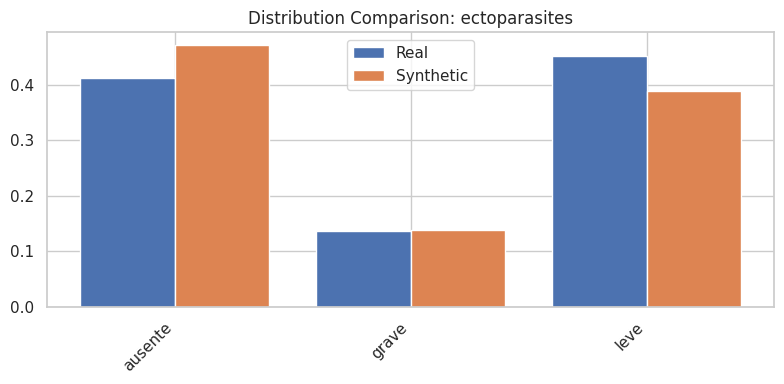

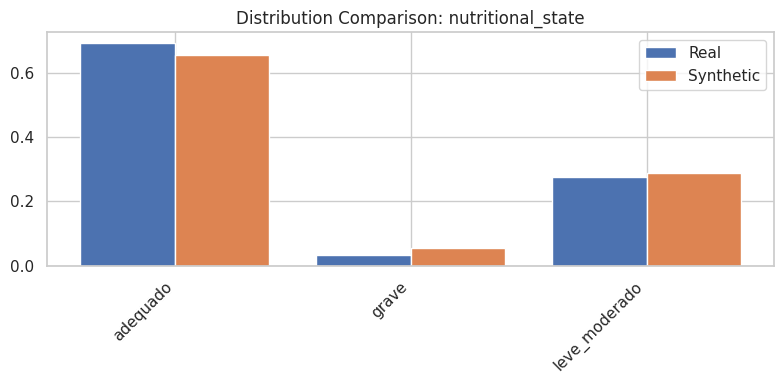

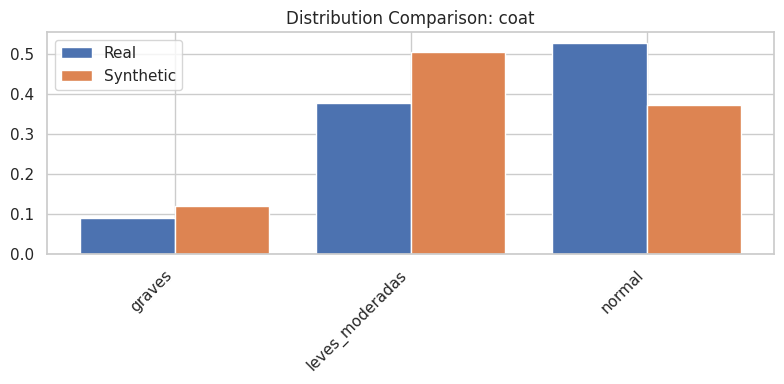

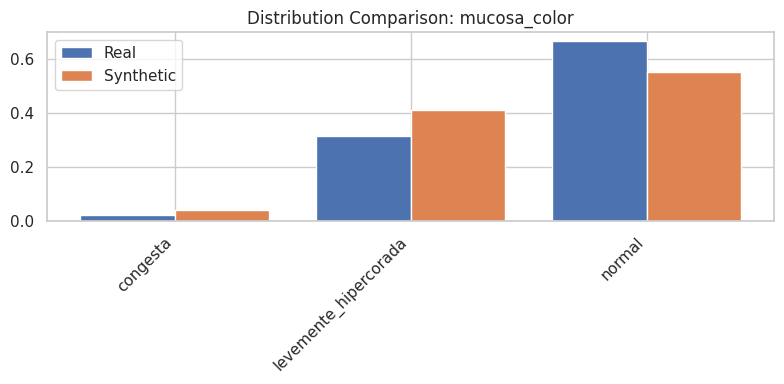

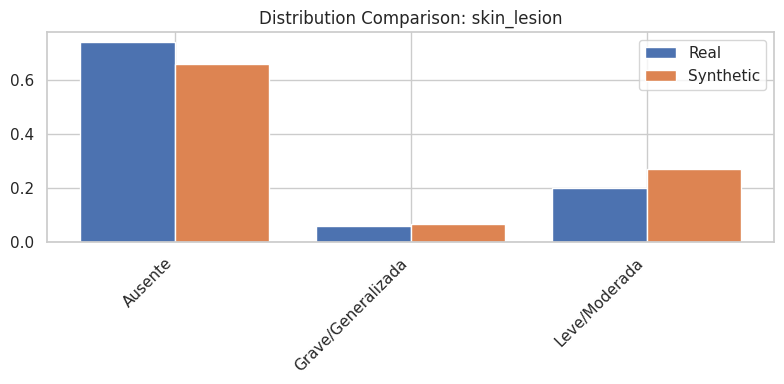

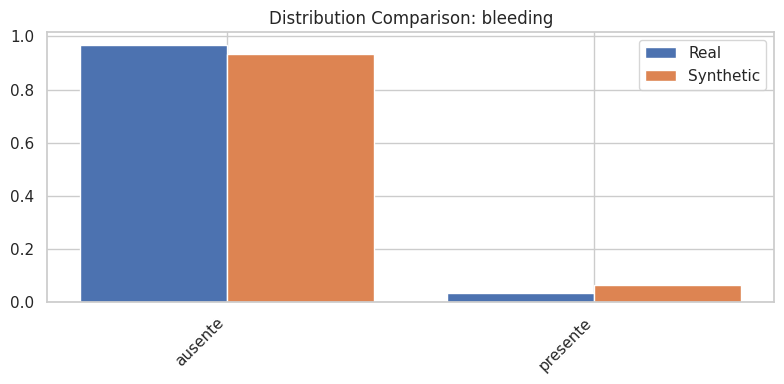

In [25]:
columns_to_plot = [
    "diagnosis",
    "general_state",
    "ectoparasites",
    "nutritional_state",
    "coat",
    "mucosa_color",
    "skin_lesion",
    "bleeding"
]

for col in columns_to_plot:
    plot_distribution_comparison(df, example_df, col)